# Spotify Popularity Prediction Part 3

## Spark Session

In [1]:
from pyspark.sql import SparkSession

# Initialize Spark session with enough memory for the 189GB dataset
# 7 executors x 25g = 175g total executor memory across the cluster

spark = (
    SparkSession.builder
    .appName("Spotify_Part3_RF")
    .config("spark.driver.memory", "10g")
    .config("spark.executor.instances", "7")
    .config("spark.executor.memory", "25g")
    .config("spark.executor.memoryOverhead", "4g") 
    .config("spark.sql.shuffle.partitions", "100")  #reduced from 200 for sample
    .getOrCreate()
)

## Load Parquet Tables

In [2]:
from pyspark.sql import functions as F

data_path = "/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet"

# Load all tables
tracks = spark.read.parquet(data_path + "/tracks.parquet")
artists = spark.read.parquet(data_path + "/artists.parquet")
albums = spark.read.parquet(data_path + "/albums.parquet")
track_artists = spark.read.parquet(data_path + "/track_artists.parquet")

# Audio features
audio = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_audio_features_parquet")

print("Data loaded")

Data loaded


## Cleaning

In [3]:
# Audio features cleaning
# Rename duration_ms to avoid confusion with tracks.duration_ms
audio = audio.withColumnRenamed("duration_ms", "audio_duration_ms")

# Drop rows with null response
audio = audio.filter(F.col("null_response").isNull())

# Cast all audio feature columns to double for ML compatibility
audio_cols = [
    "audio_duration_ms", "time_signature", "tempo",
    "key", "mode", "danceability", "energy",
    "loudness", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence"
]
for c in audio_cols:
    audio = audio.withColumn(c, F.col(c).cast("double"))

In [4]:
# Artist deduplication
# Some artists appear multiple times (ex. BTS has different entries for each member)
# Keep only the row with the highest followers_total per artist name

from pyspark.sql.window import Window

artists_clean = artists.select(
    F.col("rowid").alias("artist_rowid"),
    F.col("id"),
    F.col("name"),
    F.col("followers_total"),
    F.col("popularity").alias("artist_popularity")
)

# Window: for each artist name, rank by followers descending
w = Window.partitionBy("name").orderBy(
    F.desc("followers_total"),
    F.desc("artist_popularity")
)
artists_clean = (
    artists_clean
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") == 1)  # keep only the top row per artist name
    .drop("rank")
)

In [5]:
# Only take cols we need from each

# Tracks
tracks_clean = tracks.select(
    F.col("rowid").alias("track_rowid"),
    F.col("id").alias("track_id"),
    F.col("name").alias("track_name"),
    F.col("popularity"),           # this is our prediction target
    F.col("duration_ms").alias("track_duration"),
    F.col("explicit"),
    F.col("album_rowid")
)

# Sample before joins
# Sampling on tracks first = all 4 joins run on 1.25M rows instead of 256M
# Prevents shuffle files from filling up the executor local disk to prevent spill error
tracks_clean = tracks_clean.sample(False, 0.005, seed=42)

# Albums
albums_clean = albums.select(
    F.col("rowid").alias("album_rowid"),
    F.col("popularity").alias("album_popularity"),
    "label",
    "total_tracks"
)

## Join Pipeline

In [6]:
# Join tracks to audio features, track_artists bridge table, artists, and albums
# All joins are left so we keep tracks even if audio/artist/album data is missing

main_df = (
    tracks_clean
    # Join audio features on track_id
    .join(audio, tracks_clean.track_id == audio.track_id, "left")
    .drop(audio["track_id"])                          # drop duplicate track_id from audio
    # Join bridge table to get artist_rowid per track
    .join(track_artists, tracks_clean.track_rowid == track_artists.track_rowid, "left")
    .drop(track_artists["track_rowid"])               # drop duplicate track_rowid
    # Join artists on artist_rowid
    .join(artists_clean, track_artists.artist_rowid == artists_clean.artist_rowid, "left")
    .drop(track_artists["artist_rowid"]).drop(artists_clean["artist_rowid"])
    # Join albums on album_rowid
    .join(albums_clean, tracks_clean.album_rowid == albums_clean.album_rowid, "left")
    .drop(albums_clean["album_rowid"])                # drop duplicate album_rowid
)

In [7]:
# Deduplicate tracks
# A track with multiple artists creates multiple rows after the join
# To fix this collapse to one row per track_id using agg

df_clean = main_df.groupBy("track_id").agg(
    F.first("track_name").alias("track_name"),
    F.first("name").alias("artist_name"),             # primary artist name
    F.first("popularity").alias("popularity"),         # track popularity (our target)
    F.max("followers_total").alias("followers_total"), # take the most-followed artist
    F.max("artist_popularity").alias("artist_popularity"),
    F.first("album_popularity").alias("album_popularity"),
    F.first("total_tracks").alias("total_tracks"),
    F.first("track_duration").alias("track_duration"),
    F.first("explicit").alias("explicit"),
    *[F.first(c).alias(c) for c in audio_cols]        # all audio features
)

# Drop rows missing the target or track id
df_clean = df_clean.na.drop(subset=["popularity", "track_id"])

## Preprocessing

In [8]:
# Feature engineering
# log1p(followers) compresses the huge range of follower counts (0 to 80M+)

df_clean = df_clean.withColumn("log_followers", F.log1p(F.col("followers_total")))

# Interaction feature: energy * danceability captures "hype" tracks
df_clean = df_clean.withColumn("energy_dance", F.col("energy") * F.col("danceability"))

In [9]:
# Imputer for missing values

from pyspark.ml.feature import Imputer
from pyspark.sql import Row

toy_data = spark.createDataFrame([
    Row(followers_total=1000.0,     tempo=120.0, danceability=None, energy=0.80),
    Row(followers_total=None,       tempo=130.0, danceability=0.65, energy=None),
    Row(followers_total=500000.0,   tempo=None,  danceability=0.55, energy=0.70),
    Row(followers_total=78000000.0, tempo=110.0, danceability=0.75, energy=0.90),
])

demo_cols = ["followers_total", "tempo", "danceability", "energy"]
imputer_demo = Imputer(
    inputCols=demo_cols,
    outputCols=[c + "_imp" for c in demo_cols]
).setStrategy("mean")  # replace nulls with column mean

imputer_demo.fit(toy_data).transform(toy_data).show(truncate=False)

+---------------+-----+------------+------+-------------------+---------+----------------+------------------+
|followers_total|tempo|danceability|energy|followers_total_imp|tempo_imp|danceability_imp|energy_imp        |
+---------------+-----+------------+------+-------------------+---------+----------------+------------------+
|1000.0         |120.0|NULL        |0.8   |1000.0             |120.0    |0.65            |0.8               |
|NULL           |130.0|0.65        |NULL  |2.6167E7           |130.0    |0.65            |0.7999999999999999|
|500000.0       |NULL |0.55        |0.7   |500000.0           |120.0    |0.55            |0.7               |
|7.8E7          |110.0|0.75        |0.9   |7.8E7              |110.0    |0.75            |0.9               |
+---------------+-----+------------+------+-------------------+---------+----------------+------------------+



In [10]:
# Handle missing values on real data
# Fill nulls with 0 for all numeric feature columns
# missing audio features = track has no audio data, fill as 0

numeric_cols_full = [
    "followers_total", "artist_popularity", "album_popularity", "total_tracks",
    "track_duration", "explicit", "log_followers", "energy_dance"
] + audio_cols

df_clean = df_clean.fillna(0, subset=numeric_cols_full)

In [11]:
from pyspark.ml.feature import VectorAssembler, Normalizer

# All numeric features 
feature_cols = [
    "followers_total", "artist_popularity", "album_popularity", "total_tracks",
    "track_duration", "explicit", "log_followers", "energy_dance"
] + audio_cols

# VectorAssembler combines all feature columns into a single vector column
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="keep"  # keep rows with remaining nulls rather than dropping
)

# Normalizer scales each row's feature vector to unit norm (L2)
normalizer = Normalizer(inputCol="features_raw", outputCol="features", p=2)

# Apply assembler and normalizer
df_assembled = assembler.transform(df_clean)
df_final = normalizer.transform(df_assembled).select(
    "track_id", "track_name", "artist_name", "popularity", "features"
)

# Cache so train/val/test splits don't recompute the full join and clean process
df_final = df_final.cache()
row_count = df_final.count()  # triggers caching
print(f"Preprocessed rows: {row_count:,}")
df_final.show(5, truncate=True)

Preprocessed rows: 1,278,282
+--------------------+--------------------+--------------------+----------+--------------------+
|            track_id|          track_name|         artist_name|popularity|            features|
+--------------------+--------------------+--------------------+----------+--------------------+
|0000RM7QYBRAsuFAQ...|             Mo n Me|           Modd Jobs|         0|(21,[0,3,4,6],[5....|
|0001qtVaca5vVqHv0...|               Arena|         Kronnospace|         0|(21,[0,1,3,4,6],[...|
|000BJtGc0SLMN5ixU...|   Trịnh Vương Maria|          Thanh Hoài|         0|(21,[0,1,2,3,4,6]...|
|000Wdim8xmdzFdAds...|Emotional Intelli...|Wave Particle Sin...|         0|(21,[0,1,3,4,6],[...|
|000XiFdhd8fypmIvU...|       Escaped Pulse|      Spiritual Yoga|         0|(21,[0,1,3,4,6],[...|
+--------------------+--------------------+--------------------+----------+--------------------+
only showing top 5 rows



In [12]:
!df -h 

Filesystem                                               Size  Used Avail Use% Mounted on
overlay                                                   64M   12K   64M   1% /
tmpfs                                                    126G     0  126G   0% /dev/shm
/dev/sda2                                                 63G   19G   41G  31% /var/tmp
10.22.100.112:/pool2/home/darenas                        212T   38T  175T  18% /home/darenas
/dev/sda3                                                 20G  4.7G   14G  26% /tmp
tmpfs                                                     64M   12K   64M   1% /etc/group
ps-071.sdsc.edu:/ps-data/community-sw                    1.0T  324G  701G  32% /expanse/community
10.22.100.111:/pool1/home                                214T   30T  185T  14% /expanse/nfs/home1
master:/home                                             140G  102G   39G  73% /expanse/nfs/mgr1/home
10.22.100.114:/pool4/home                                213T   32T  181T  15% /expanse/

## Train / Validation / Test Split

In [13]:
# 70% train, 15% validation, 15% test

train_df, val_df, test_df = df_final.randomSplit([0.7, 0.15, 0.15], seed=42)

print(f"Train:      {train_df.count():,}")
print(f"Validation: {val_df.count():,}")
print(f"Test:       {test_df.count():,}")

Train:      895,418
Validation: 191,376
Test:       191,488


## Distributed Random Forest: Model 1

In [14]:
from pyspark.ml.regression import RandomForestRegressor

# Model 1: starting point for hyperparameters 
# Using regression since popularity is a continuous 0-100 score

rf = RandomForestRegressor(
    labelCol="popularity",
    featuresCol="features",
    numTrees=50,    
    maxDepth=8,  
    featureSubsetStrategy="auto",
    seed=42
)

print("Fitting Model 1 (numTrees=50, maxDepth=8)")
rf_model = rf.fit(train_df)
print("Done")

Fitting Model 1 (numTrees=50, maxDepth=8)
Done


## Evaluation (Train vs Validation vs Test)

In [15]:
from pyspark.ml.evaluation import RegressionEvaluator

eval_rmse = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="rmse")
eval_r2   = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="r2")

# Predict on all 3 splits
pred_train = rf_model.transform(train_df)
pred_val   = rf_model.transform(val_df)
pred_test  = rf_model.transform(test_df)

print("Model 1: numTrees=50, maxDepth=8")
print(f"RMSE  train={eval_rmse.evaluate(pred_train):.3f}  val={eval_rmse.evaluate(pred_val):.3f}  test={eval_rmse.evaluate(pred_test):.3f}")
print(f"R2    train={eval_r2.evaluate(pred_train):.3f}    val={eval_r2.evaluate(pred_val):.3f}    test={eval_r2.evaluate(pred_test):.3f}")

Model 1: numTrees=50, maxDepth=8
RMSE  train=2.709  val=2.757  test=2.722
R2    train=0.708    val=0.707    test=0.708


In [16]:
cols_to_show = ["track_name", "artist_name", "popularity", "prediction"]

print("Train examples")
pred_train.select(*cols_to_show)\
    .filter(F.col("track_name") != "")\
    .filter(F.col("popularity") > 0)\
    .orderBy(F.desc("popularity"))\
    .show(10, truncate=False)

print("Validation examples")
pred_val.select(*cols_to_show)\
    .filter(F.col("track_name") != "")\
    .filter(F.col("popularity") > 0)\
    .orderBy(F.desc("popularity"))\
    .show(10, truncate=False)

print("Test examples")
pred_test.select(*cols_to_show)\
    .filter(F.col("track_name") != "")\
    .filter(F.col("popularity") > 0)\
    .orderBy(F.desc("popularity"))\
    .show(10, truncate=False)

Train examples
+-----------------------+---------------+----------+------------------+
|track_name             |artist_name    |popularity|prediction        |
+-----------------------+---------------+----------+------------------+
|Pink Pony Club         |Chappell Roan  |87        |23.91461171554553 |
|LOVE. FEAT. ZACARI.    |Zacari         |85        |16.912389610866533|
|Atlantis               |Seafret        |84        |31.684222660225995|
|Chasing Cars           |Snow Patrol    |83        |22.174647397323096|
|Hey Brother            |Avicii         |81        |16.912389610866533|
|Where Is The Love?     |Black Eyed Peas|81        |24.502895552123164|
|Cantada Boba - Ao Vivo |Jorge & Mateus |80        |16.912389610866533|
|White Flag             |Dido           |78        |26.528025617479763|
|Somebody (2024)        |Sante Sansone  |78        |30.727481702739098|
|Going Bad (feat. Drake)|Drake          |77        |16.170899281407145|
+-----------------------+---------------+--------

## Hyperparameter Comparison: Model 2

In [17]:
# Model 2: deeper trees and more trees to test for overfitting

rf2 = RandomForestRegressor(
    labelCol="popularity",
    featuresCol="features",
    numTrees=100,
    maxDepth=12,
    featureSubsetStrategy="auto",
    seed=42
)

print("Fitting Model 2 (numTrees=100, maxDepth=12)")
rf_model2 = rf2.fit(train_df)
print("Done")

pred_train2 = rf_model2.transform(train_df)
pred_val2   = rf_model2.transform(val_df)
pred_test2  = rf_model2.transform(test_df)

print("Model 2: numTrees=100, maxDepth=12")
print(f"RMSE  train={eval_rmse.evaluate(pred_train2):.3f}  val={eval_rmse.evaluate(pred_val2):.3f}  test={eval_rmse.evaluate(pred_test2):.3f}")
print(f"R2    train={eval_r2.evaluate(pred_train2):.3f}    val={eval_r2.evaluate(pred_val2):.3f}    test={eval_r2.evaluate(pred_test2):.3f}")

Fitting Model 2 (numTrees=100, maxDepth=12)
Done
Model 2: numTrees=100, maxDepth=12
RMSE  train=2.504  val=2.587  test=2.560
R2    train=0.751    val=0.742    test=0.742


## Feature Importance

In [18]:
# Feature importances from Model 1
# Higher value = more useful for predicting popularity

import pandas as pd

fi_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.featureImportances.toArray()
}).sort_values("importance", ascending=False)

print("Feature importances (Model 1):")
print(fi_df.to_string(index=False))

Feature importances (Model 1):
          feature  importance
 album_popularity    0.620257
     total_tracks    0.213915
   track_duration    0.062000
  followers_total    0.048010
artist_popularity    0.029234
    log_followers    0.022796
         explicit    0.003787
           energy    0.000000
         liveness    0.000000
 instrumentalness    0.000000
     acousticness    0.000000
      speechiness    0.000000
         loudness    0.000000
            tempo    0.000000
     danceability    0.000000
             mode    0.000000
              key    0.000000
   time_signature    0.000000
audio_duration_ms    0.000000
     energy_dance    0.000000
          valence    0.000000


# 2nd model using ray

In [19]:
!python -m pip install --user --no-cache-dir "ray[data]" "ray[train]" xgboost

In [20]:
#Using Scratch for temp disk space

In [21]:
import os
from pyspark.ml.functions import vector_to_array

USER = os.environ.get("USER", "user")
BASE = f"/expanse/lustre/scratch/{USER}/temp_project"

RAY_PCA_IN = f"{BASE}/ray_pca_input"
(
    
    df_final
        .select(
        "track_id",
        "popularity",
        "track_name",
        "artist_name",
            
        vector_to_array("features").alias("x")# convert Spark vector -> array<double>
    )
    .write.mode("overwrite").parquet(RAY_PCA_IN)
)
print("Wrote PCA input for Ray to:", RAY_PCA_IN)


Wrote PCA input for Ray to: /expanse/lustre/scratch/darenas/temp_project/ray_pca_input


In [22]:
#Start Ray locally in notebook (with scratch spilling)
#Ray can spill objects to disk when memory is pressured; set object_spilling_directory to scratch to avoid disk issues

In [23]:
import ray
import os

RAY_SPILL = f"{BASE}/ray_spill"
os.makedirs(RAY_SPILL, exist_ok=True)

ray.shutdown()
ray.init(num_cpus=8, object_spilling_directory=RAY_SPILL)

print("Ray version:", ray.__version__)
print("Ray resources:", ray.cluster_resources())
print("Ray spill dir:", RAY_SPILL)


2026-05-30 10:03:52,034	INFO worker.py:2003 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Ray version: 2.55.1
Ray resources: {'node:__internal_head__': 1.0, 'CPU': 8.0, 'memory': 177954465383.0, 'object_store_memory': 76266199449.0, 'node:198.202.103.218': 1.0}
Ray spill dir: /expanse/lustre/scratch/darenas/temp_project/ray_spill


/home/darenas/.local/lib/python3.11/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


print(ray.cluster_resources())

# Step 1 RAY PCA Distrubted 
1A) Read parquet
 ray reads parquet as a ray dataset

In [24]:
import ray.data as rd

ds = rd.read_parquet(RAY_PCA_IN)
print(ds.schema())

Parquet dataset sampling:   0%|          | 0.00/2.00 [00:00<?, ? file/s]

2026-05-30 10:03:55,496	INFO parquet_datasource.py:1133 -- Estimated parquet encoding ratio is 2.389.
2026-05-30 10:03:55,496	INFO parquet_datasource.py:1193 -- Estimated parquet reader batch size at 540114 rows


Column       Type
------       ----
track_id     string
popularity   int64
track_name   string
artist_name  string
x            list<element: double not null>


A2) Compute PCA using distributed batch aggregation (map_batches)
map_batches is the right pattern for fast batch/NumPy-style transforms in Ray Data

In [25]:
#map_batches is the way to distrbute the data = faster runtime
#Role of Function: Computes Global mean and covariance by aggreagating sum x and sum of xxT

import numpy as np

def batch_sums(batch): 
        # batch is a dict of numpy arrays when batch_format = numpy
        #shape:(n,d)
        X = np.vstack(batch["x"])   
        n = X.shape[0]
        #(d,)
        sum_x = X.sum(axis= 0)
        #(d, d)
        sum_xxT = X.T @ X                  
        return {"n": [n], "sum_x": [sum_x], "sum_xxT": [sum_xxT]}


In [26]:
#Aggregate stats over dataset blocks in parallel
stats_ds = ds.map_batches(batch_sums, batch_format="numpy", batch_size=50000)
partials = stats_ds.take_all()

N = int(sum(p["n"] for p in partials))
sum_x = np.sum([p["sum_x"] for p in partials], axis=0)
sum_xxT = np.sum([p["sum_xxT"] for p in partials], axis=0)

mean = sum_x / N
cov = (sum_xxT / N) - np.outer(mean, mean)


2026-05-30 10:03:56,169	INFO logging.py:416 -- Registered dataset logger for dataset dataset_1_0
2026-05-30 10:03:56,305	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_1_0. Full logs are in /scratch/darenas/job_49895371/ray/session_2026-05-30_10-03-40_227186_750958/logs/ray-data
2026-05-30 10:03:56,305	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_1_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> TaskPoolMapOperator[MapBatches(batch_sums)]
2026-05-30 10:03:56,314	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 42.9% of available memory (71.0GiB out of 165.7GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.
2026-05-30 10:03:56,321	INFO __init__.py:56 --

In [27]:
# Eigen-decomposition of covariance -> PCA components
eigvals, eigvecs = np.linalg.eigh(cov)     # ascending
idx = np.argsort(eigvals)[::-1]            # descending
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]


In [28]:
explained_var_ratio = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained_var_ratio)

print("Top 10 explained variance ratios:", explained_var_ratio[:10])
print("Cumulative explained variance (top 10):", cum_explained[:10])
print("Feature dimension d =", eigvecs.shape[0])


Top 10 explained variance ratios: [9.70881511e-01 2.90509205e-02 6.73718662e-05 1.64638923e-07
 2.27695394e-08 9.68458128e-09 6.89043255e-11 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
Cumulative explained variance (top 10): [0.97088151 0.99993243 0.9999998  0.99999997 0.99999999 1.
 1.         1.         1.         1.        ]
Feature dimension d = 21


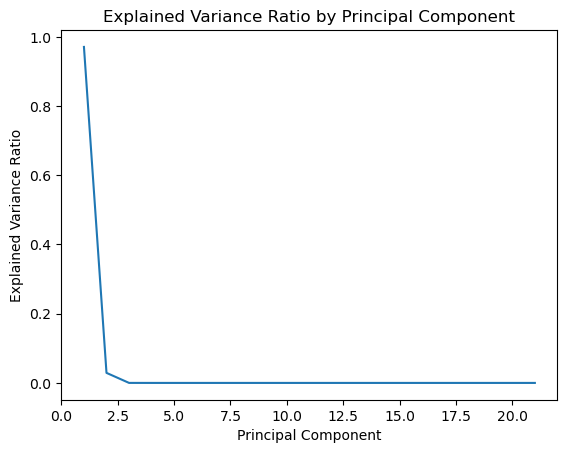

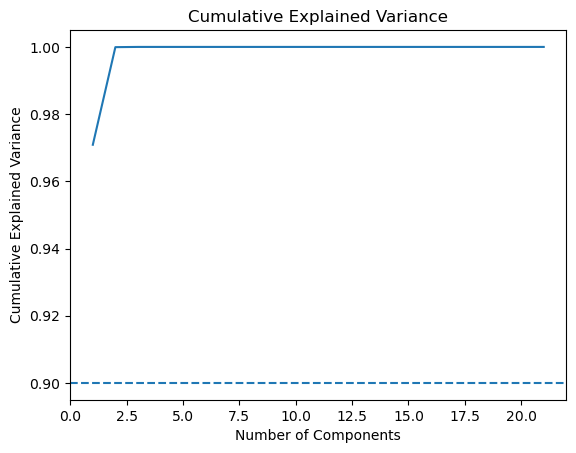

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio)
plt.title("Explained Variance Ratio by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

plt.figure()
plt.plot(range(1, len(cum_explained) + 1), cum_explained)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.axhline(0.90, linestyle="--")
plt.show()

PCA Interpretation
The explained variance plot shows that the first principal component captures approximately 97% of the total variance in the dataset, while the second component captures a small additional portion (~2–3%). All remaining components contribute negligible variance.
The cumulative explained variance indicates that over 99% of the total variance is captured using only the first two principal components. This suggests that the original feature space contains significant redundancy, and that most of the information can be effectively represented in a much lower-dimensional space.

In [30]:
K = int(np.searchsorted(cum_explained, 0.90) + 1)
print("Selected K to retain ~90% variance:", K)

W = eigvecs[:, :K]   # (d, K)
mu = mean            # (d,)

Selected K to retain ~90% variance: 1


In [31]:
def project_batch(batch):
    X = np.vstack(batch["x"])
    Z = (X - mu) @ W                      # (n, K)
    batch["pca"] = [row.tolist() for row in Z]
    return batch

ds_pca = ds.map_batches(project_batch, batch_format="numpy", batch_size=50000)

In [32]:
RAY_PCA_OUT = f"{BASE}/ray_pca_output"
ds_pca.write_parquet(RAY_PCA_OUT)
print("Wrote Ray PCA output to:", RAY_PCA_OUT)

2026-05-30 10:04:01,293	INFO logging.py:416 -- Registered dataset logger for dataset dataset_4_0
2026-05-30 10:04:01,298	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_4_0. Full logs are in /scratch/darenas/job_49895371/ray/session_2026-05-30_10-03-40_227186_750958/logs/ray-data
2026-05-30 10:04:01,298	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_4_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> TaskPoolMapOperator[MapBatches(project_batch)->Write]
2026-05-30 10:04:01,321	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_4_0 =======
2026-05-30 10:04:01,321	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-30 10:04:01,322	INFO logging_progress.py:227 -- Active & requested resources: 0/8 CPU, 0.0B/35.5GiB object store
2026-05-30 10:04:01,322	INFO logging_progress.py:181 -- 
2026-05-30 10:04:01,322	INFO logging_progress.py:231 -- ReadParquet->SplitBlocks(23): 0/1
2026-05-30 10:04:01,323	INFO logging_

Wrote Ray PCA output to: /expanse/lustre/scratch/darenas/temp_project/ray_pca_output


# Use Ray Train + XGBoost after PCA

In [33]:
#1) Split your PCA Ray dataset into train / validation / test

train_ds, rest_ds = ds_pca.train_test_split(test_size=0.3, seed=42)
val_ds, test_ds = rest_ds.train_test_split(test_size=0.5, seed=42)

print("Ray splits created")

2026-05-30 10:04:05,714	INFO logging.py:416 -- Registered dataset logger for dataset dataset_6_0
2026-05-30 10:04:05,717	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_6_0. Full logs are in /scratch/darenas/job_49895371/ray/session_2026-05-30_10-03-40_227186_750958/logs/ray-data
2026-05-30 10:04:05,718	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_6_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> TaskPoolMapOperator[MapBatches(project_batch)]
2026-05-30 10:04:05,735	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_6_0 =======
2026-05-30 10:04:05,736	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-30 10:04:05,736	INFO logging_progress.py:227 -- Active & requested resources: 0/8 CPU, 0.0B/35.5GiB object store
2026-05-30 10:04:05,736	INFO logging_progress.py:181 -- 
2026-05-30 10:04:05,737	INFO logging_progress.py:231 -- ReadParquet->SplitBlocks(23): 0/1
2026-05-30 10:04:05,737	INFO logging_progres

Ray splits created


In [34]:
def expand_pca(batch):
    P = np.vstack(batch["pca"])  # shape (n, K)
    out = {f"pc{i+1}": P[:, i] for i in range(P.shape[1])}
    out["track_id"] = batch["track_id"]
    out["track_name"] = batch["track_name"]
    out["artist_name"] = batch["artist_name"]
    #label
    out["popularity"] = batch["popularity"]
    return out

train_ds_tab = train_ds.map_batches(expand_pca, batch_format="numpy", batch_size=50000)
val_ds_tab   = val_ds.map_batches(expand_pca, batch_format="numpy", batch_size=50000)
test_ds_tab  = test_ds.map_batches(expand_pca, batch_format="numpy", batch_size=50000)

In [35]:
train_ds_tab = train_ds_tab.materialize()
val_ds_tab   = val_ds_tab.materialize()
test_ds_tab  = test_ds_tab.materialize()

print("Datasets materialized and ready for training.")

2026-05-30 10:04:09,025	INFO logging.py:416 -- Registered dataset logger for dataset dataset_15_0
2026-05-30 10:04:09,027	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_15_0. Full logs are in /scratch/darenas/job_49895371/ray/session_2026-05-30_10-03-40_227186_750958/logs/ray-data
2026-05-30 10:04:09,027	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_15_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(expand_pca)]
2026-05-30 10:04:09,043	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_15_0 =======
2026-05-30 10:04:09,044	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-30 10:04:09,044	INFO logging_progress.py:227 -- Active & requested resources: 0/8 CPU, 0.0B/35.5GiB object store
2026-05-30 10:04:09,045	INFO logging_progress.py:181 -- 
2026-05-30 10:04:09,045	INFO logging_progress.py:231 -- MapBatches(expand_pca): 0/1
2026-05-30 10:04:09,045	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued

Datasets materialized and ready for training.


In [38]:
import xgboost
import time
import ray.train
from ray.train import ScalingConfig
from ray.train.xgboost import XGBoostTrainer, RayTrainReportCallback

def train_xgb_per_worker(config):
    # Get this worker's shard of each dataset
    train_shard = ray.train.get_dataset_shard("train")
    val_shard   = ray.train.get_dataset_shard("validation")

    # Materialize shard -> pandas
    train_df = train_shard.materialize().to_pandas()
    val_df   = val_shard.materialize().to_pandas()

    # Split into X / y
    train_X = train_df.drop(columns=["popularity", "track_id", "track_name", "artist_name"])
    train_y = train_df["popularity"]

    val_X = val_df.drop(columns=["popularity", "track_id", "track_name", "artist_name"])
    val_y = val_df["popularity"]

    # Build DMatrix objects
    dtrain = xgboost.DMatrix(train_X, label=train_y)
    dval   = xgboost.DMatrix(val_X, label=val_y)

    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "max_depth": 6,
        "eta": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "rmse",
    }

    xgboost.train(
        params=params,
        dtrain=dtrain,
        evals=[(dval, "validation")],
        num_boost_round=300,
        callbacks=[RayTrainReportCallback()],
    )

trainer = XGBoostTrainer(
    train_xgb_per_worker,
    datasets={
        "train": train_ds_tab,
        "validation": val_ds_tab,
    },
    scaling_config=ScalingConfig(
        num_workers=3,
        resources_per_worker={"CPU": 2}
    ),
)



In [39]:
result = trainer.fit()
print("Training complete")
print(result.metrics)

(TrainController pid=761800) Requesting resources: {'CPU': 2} * 3
(TrainController pid=761800) Attempting to start training worker group of size 3 with the following resources: [{'CPU': 2}] * 3
(TrainController pid=761800) Started training worker group of size 3: 
(TrainController pid=761800) - (ip=198.202.103.218, pid=761873) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=761800) - (ip=198.202.103.218, pid=761871) world_rank=1, local_rank=1, node_rank=0
(TrainController pid=761800) - (ip=198.202.103.218, pid=761872) world_rank=2, local_rank=2, node_rank=0
(RayTrainWorker pid=761873) [10:12:17] Task [xgboost.ray-rank=00000000]:1b77d31593361b991f1c3c0501000000 got rank 0
(SplitCoordinator pid=762186) Registered dataset logger for dataset train_31_0
(SplitCoordinator pid=762186) Starting execution of Dataset train_31_0. Full logs are in /scratch/darenas/job_49895371/ray/session_2026-05-30_10-03-40_227186_750958/logs/ray-data
(SplitCoordinator pid=762186) Execution plan of D

(pid=762186) Running Dataset train_31_0.: 0.00 row [00:00, ? row/s]

(pid=762186) - split(3, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=761872) Running Dataset dataset_35_0.: 0.00 row [00:00, ? row/s]

(RayTrainWorker pid=761872) 
(RayTrainWorker pid=761872) 
(RayTrainWorker pid=761872) ✔️  Dataset dataset_35_0 execution finished in 0.00 seconds


...

(pid=761871) Running Dataset dataset_40_0.: 0.00 row [00:00, ? row/s]

(RayTrainWorker pid=761871) 
(RayTrainWorker pid=761871) 


(pid=761872) Running Dataset dataset_38_0.: 0.00 row [00:00, ? row/s]

(RayTrainWorker pid=761872) 
(RayTrainWorker pid=761872) 
(TrainController pid=761800) [10:12:19] [0]	validation-rmse:5.02923
(RayTrainWorker pid=761873) Reporting training result 1: TrainingReport(checkpoint=None, metrics=OrderedDict([('validation-rmse', 5.029231921747874)]), validation=False)
(RayTrainWorker pid=761873) Reporting training result 2: TrainingReport(checkpoint=None, metrics=OrderedDict([('validation-rmse', 5.013247178650718)]), validation=False)
(TrainController pid=761800) [10:12:19] [1]	validation-rmse:5.01325
(TrainController pid=761800) [10:12:21] [2]	validation-rmse:4.99876
(TrainController pid=761800) [10:12:23] [3]	validation-rmse:4.98558
(RayTrainWorker pid=761872) [10:12:17] Task [xgboost.ray-rank=00000002]:dc9aac14fcf1853049f0775801000000 got rank 2 [repeated 2x across cluster]
(RayTrainWorker pid=761872) Registered dataset logger for dataset dataset_38_0 [repeated 7x across cluster]
(SplitCoordinator pid=762187) Starting execution of Dataset validation_33_0. 

Training complete
OrderedDict([('validation-rmse', 4.860521958351648)])


In [41]:
from sklearn.metrics import mean_squared_error, r2_score

# Get trained model from checkpoint
checkpoint = result.checkpoint
booster = RayTrainReportCallback.get_model(checkpoint)

print("Loaded trained XGBoost model from Ray")

#  Load test data from Ray → pandas
test_df = test_ds_tab.materialize().to_pandas()

# Split features and label
y_test = test_df["popularity"]
X_test = test_df.drop(columns=["popularity", "track_id", "track_name", "artist_name"])

# Convert to DMatrix
dtest = xgboost.DMatrix(X_test, label=y_test)

# Make predictions
pred_test = booster.predict(dtest)

# Metrics
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_test = r2_score(y_test, pred_test)

print("=== MODEL 2: Ray PCA + XGBoost (TEST) ===")
print("RMSE test:", rmse_test)
print("R2 test  :", r2_test)

Loaded trained XGBoost model from Ray
=== MODEL 2: Ray PCA + XGBoost (TEST) ===
RMSE test: 4.870841547763875
R2 test  : 0.07026624759199396


The XGBoost model achieved a validation RMSE of approximately 4.86, meaning that predictions deviate from the true popularity values by about 5 points on average.
However, the corresponding R² score is low (~0.07), indicating that the model explains only a small portion of the variance in the target variable. This suggests that while predictions are reasonably close numerically, the model is not capturing strong predictive patterns in the data.
This result implies that either the available features are weak predictors of popularity or that the relationship between features and popularity is complex and difficult to model.

In [42]:
pred_test = spark.createDataFrame(test_df)

pred_test.orderBy(F.desc("popularity")).show(10, truncate=False)

+-------------------+----------------------+-------------------------------------------------------------+-----------------+----------+
|pc1                |track_id              |track_name                                                   |artist_name      |popularity|
+-------------------+----------------------+-------------------------------------------------------------+-----------------+----------+
|-1.2530206726806128|6393yGahSJ9slVdOwSxOVR|Pink Pony Club                                               |Chappell Roan    |87        |
|-1.2034821420368365|6si71supnBUhddjR2FJc2L|White Flag                                                   |Dido             |78        |
|-1.279901242082968 |6mTvwBzWTGDOVeCNQEqtOE|Soch Na Sake                                                 |Arijit Singh     |76        |
|-1.092953966279768 |5ds1Hh3lo4JUF2vflqyayK|Manos de Tijera                                              |Yiyo Sarante     |72        |
|-1.2473007809081365|5h5TUj8pU2WhdSeJx9BnX2|Pele

In [43]:
# ----- TRAIN PREDICTIONS -----

# Convert Ray → pandas
train_df = train_ds_tab.to_pandas()

# Split features + label
y_train = train_df["popularity"]

X_train = train_df.drop(columns=[
    "popularity",
    "track_id",
    "track_name",
    "artist_name"
])

# Predict
dtrain = xgboost.DMatrix(X_train)
train_preds = booster.predict(dtrain)

# Add predictions back
train_df["prediction"] = train_preds

# Convert to Spark (for .show())
pred_train = spark.createDataFrame(train_df)

In [44]:
print("Train examples")

pred_train.select(
    "track_id",
    "track_name",
    "artist_name",
    "popularity",
    "prediction"
)\
.orderBy(F.desc("popularity"))\
.show(10, truncate=False)

Train examples
+----------------------+-------------------------+---------------+----------+------------------+
|track_id              |track_name               |artist_name    |popularity|prediction        |
+----------------------+-------------------------+---------------+----------+------------------+
|6PGoSes0D9eUDeeAafB2As|LOVE. FEAT. ZACARI.      |Zacari         |85        |4.228507995605469 |
|1Fid2jjqsHViMX6xNH70hE|Atlantis                 |Seafret        |84        |4.937741279602051 |
|3MJ6lFNV12FSHAOzTzkwxz|Smile                    |Morgan Wallen  |83        |3.7434191703796387|
|5hnyJvgoWiQUYZttV4wXy6|Chasing Cars             |Snow Patrol    |83        |3.982858896255493 |
|0xmjwnQ3FNE6HuWCt2nHdZ|Where Is The Love?       |Black Eyed Peas|81        |4.032284736633301 |
|4lhqb6JvbHId48OUJGwymk|Hey Brother              |Avicii         |81        |4.228507995605469 |
|3QQvSQKV8YmQxGolwwWe59|CATFISH                  |Doechii        |81        |3.8685245513916016|
|2gfn28JSINCJGL

In [ ]:
# ----- VALIDATION PREDICTIONS -----

val_df = val_ds_tab.to_pandas()

y_val = val_df["popularity"]

X_val = val_df.drop(columns=[
    "popularity",
    "track_id",
    "track_name",
    "artist_name"
])

dval = xgboost.DMatrix(X_val)
val_preds = booster.predict(dval)

val_df["prediction"] = val_preds

pred_val = spark.createDataFrame(val_df)


In [45]:
pred_val.select(
    "track_id",
    "track_name",
    "artist_name",
    "popularity",
    "prediction"
)\
.orderBy(F.desc("popularity"))\
.show(10, truncate=False)

+----------------------+-------------------------------------------------------------+---------------+----------+------------------+
|track_id              |track_name                                                   |artist_name    |popularity|prediction        |
+----------------------+-------------------------------------------------------------+---------------+----------+------------------+
|3MJ6lFNV12FSHAOzTzkwxz|Smile                                                        |Morgan Wallen  |83        |23.029893123381044|
|3QQvSQKV8YmQxGolwwWe59|CATFISH                                                      |Doechii        |81        |27.883802521746585|
|2x8evxqUlF0eRabbW2JBJd|Fluorescent Adolescent                                       |Arctic Monkeys |78        |16.912389610866533|
|3B32IYD2zmDza2Pp17xqgV|Dein Mann Freestyle                                          |benno!         |73        |28.342502759854682|
|7n5QRJlaXL5a3LCjOwsdcs|YEDA YUNG                                    